# Part 3: Model Development and Evaluation
### Sydney Housing Price Prediction — Kellyville, Cherrybrook, Blacktown

This notebook builds on the Part 2 EDA. Three things came out of that notebook that shape the
modelling approach here:

- **Suburb is by far the strongest signal** in the data, with very little price overlap between
  the three suburbs.
- **Land size and bedrooms matter, but weakly on their own** — the expectation from Part 2 was
  that a bedrooms×suburb interaction would matter more than either feature alone.
- **~232 sold properties total**, with real missingness (land size, sale date) that needs to be
  handled rather than dropped, per the imputation-plus-flag approach decided in Part 2.

The dataset is also small by ML standards — 232 rows is a lot of manual data entry, but it is
not a lot of data for anything more flexible than a fairly simple model, which is directly
relevant to the model choice and the overfitting discussion below.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

df = pd.read_csv("master_dataset.csv", parse_dates=["sale_date"])
df.shape

(232, 19)

## 3.1 Feature preparation

Turning the Part 2 decisions into actual columns:

- `land_size_sqm`: impute missing values with the **suburb median** (not the global median,
  since suburb is such a strong price driver on its own) and keep the existing
  `land_size_missing` flag as a feature in its own right.
- `sale_year`: derived from `sale_date`. The 3 rows with no stated sale date get the suburb
  median sale year, with `sale_date_missing` kept as a feature (it's already 1/0 in the merged
  dataset from Part 1's cleaning step).
- **Bedrooms×suburb interaction**: explicit numeric columns (`bedrooms_if_<suburb>`) so the
  linear model gets direct access to the interaction Part 2 flagged as likely to matter — the
  tree-based models below can find this interaction on their own, but it costs nothing to give
  it to all three models on equal footing.
- `suburb` and `property_type` are one-hot encoded.
- `sale_method`, `distance_to_cbd_km` and `agent_description_snippet` are dropped: the first is
  only populated for Blacktown, and the other two are missing for effectively the entire
  dataset (Part 1/2).

In [10]:
data = df.copy()

# suburb-median imputation for land size, with a missingness flag already present
data["land_size_sqm"] = data.groupby("suburb")["land_size_sqm"].transform(
    lambda s: s.fillna(s.median())
)

# sale_year, with suburb-median imputation for the 3 rows with no stated sale date
data["sale_year"] = data["sale_date"].dt.year
suburb_median_year = data.groupby("suburb")["sale_year"].transform("median")
data["sale_year"] = data["sale_year"].fillna(suburb_median_year).astype(int)

# explicit bedrooms x suburb interaction terms
for suburb in data["suburb"].unique():
    col = f"bedrooms_if_{suburb.lower()}"
    data[col] = np.where(data["suburb"] == suburb, data["bedrooms"], 0)

feature_cols = [
    "bedrooms", "bathrooms", "parking", "land_size_sqm", "land_size_missing",
    "sale_year", "sale_date_missing", "suburb", "property_type",
] + [c for c in data.columns if c.startswith("bedrooms_if_")]

X = data[feature_cols].copy()
y = data["sale_price"].copy()

X.head()

,bedrooms,bathrooms,parking,land_size_sqm,land_size_missing,sale_year,sale_date_missing,suburb,property_type,bedrooms_if_kellyville,bedrooms_if_cherrybrook,bedrooms_if_blacktown
0,5,3,2,502.0,False,2026,False,Kellyville,House,5,0,0
1,3,2,1,743.0,False,2026,False,Kellyville,House,3,0,0
2,3,2,2,421.0,False,2026,False,Kellyville,House,3,0,0
3,3,4,2,845.0,False,2026,False,Kellyville,House,3,0,0
4,4,2,2,420.0,False,2026,False,Kellyville,House,4,0,0


## 3.2 Model selection — and a prediction, made before training

Three regression approaches were chosen specifically to represent different modelling
philosophies, not just different libraries:

1. **Linear Regression** — the interpretable baseline. It can only combine features additively
   (plus whatever interaction terms are handed to it explicitly, like `bedrooms_if_<suburb>`
   above), so it acts as a floor: if the tree-based models can't beat it by much, that's a sign
   the extra complexity isn't buying much on this dataset.
2. **Random Forest** — an averaging (bagging) ensemble of decision trees. It can capture
   non-linear relationships and interactions automatically (e.g. suburb × bedrooms, suburb ×
   land size) without them being hand-engineered, and averaging over many trees tends to keep
   variance in check on smaller datasets like this one.
3. **Gradient Boosting** — a sequential (boosting) ensemble. Also tree-based and non-linear, but
   it builds trees to correct the previous trees' errors rather than averaging independent
   trees, which usually gives it more raw flexibility — and more capacity to overfit — than a
   Random Forest of similar size.

**Prediction, before running anything:** Random Forest is expected to perform best on
cross-validated metrics. The EDA in Part 2 showed a real but non-linear suburb×bedrooms
interaction, which should give both ensembles an edge over plain Linear Regression — but with
only 232 rows split across 5 folds (~46 rows per validation fold), Gradient Boosting's extra
flexibility is expected to show up mostly as *overfitting* rather than better generalisation,
while Random Forest's averaging should make it more robust to a small sample. Linear Regression
is expected to sit clearly behind both ensembles, but not by a huge margin, since suburb (its
strongest predictor) is handed to it directly as a one-hot feature.

In [11]:
numeric_features = [
    "bedrooms", "bathrooms", "parking", "land_size_sqm", "land_size_missing",
    "sale_year", "sale_date_missing",
] + [c for c in X.columns if c.startswith("bedrooms_if_")]
categorical_features = ["suburb", "property_type"]

def make_pipeline(model, scale_numeric=False):
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))
    numeric_transformer = Pipeline(numeric_steps)

    categorical_transformer = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])

    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    # sale_price is right-skewed (Part 2, section 2.2) - train/evaluate in log space,
    # metrics below are still reported back on the original dollar scale
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

models = {
    "Linear Regression": make_pipeline(LinearRegression(), scale_numeric=True),
    "Random Forest": make_pipeline(
        RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
    ),
    "Gradient Boosting": make_pipeline(
        GradientBoostingRegressor(random_state=RANDOM_STATE)
    ),
}
list(models.keys())

['Linear Regression', 'Random Forest', 'Gradient Boosting']

## 3.3 5-fold cross-validation

Same fold split used for every model, so the comparison is fair. Metrics: R² (variance
explained), MAE and RMSE (both in dollars, so they're directly interpretable — RMSE penalises
large misses more than MAE does).

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
}

cv_results = {}
for name, pipe in models.items():
    res = cross_validate(pipe, X, y, cv=kf, scoring=scoring,
                          return_train_score=True, n_jobs=-1)
    cv_results[name] = res

summary = pd.DataFrame({
    name: {
        "CV R2 (mean)": res["test_r2"].mean(),
        "CV R2 (std)": res["test_r2"].std(),
        "Train R2 (mean)": res["train_r2"].mean(),
        "CV MAE ($)": -res["test_mae"].mean(),
        "CV RMSE ($)": -res["test_rmse"].mean(),
    }
    for name, res in cv_results.items()
}).T
summary.round(3)

,CV R2 (mean),CV R2 (std),Train R2 (mean),CV MAE ($),CV RMSE ($)
Linear Regression,0.822,0.059,0.867,172965.805,281519.229
Random Forest,0.843,0.051,0.977,139804.083,264581.313
Gradient Boosting,0.814,0.079,0.968,154831.125,285238.211


`Train R2` is the score each model gets on the same data it was fitted on, within each
fold — comparing it to `CV R2` (the held-out score) is the standard way to check for
overfitting: a big gap between the two means the model is memorising the training folds rather
than learning something that generalises.

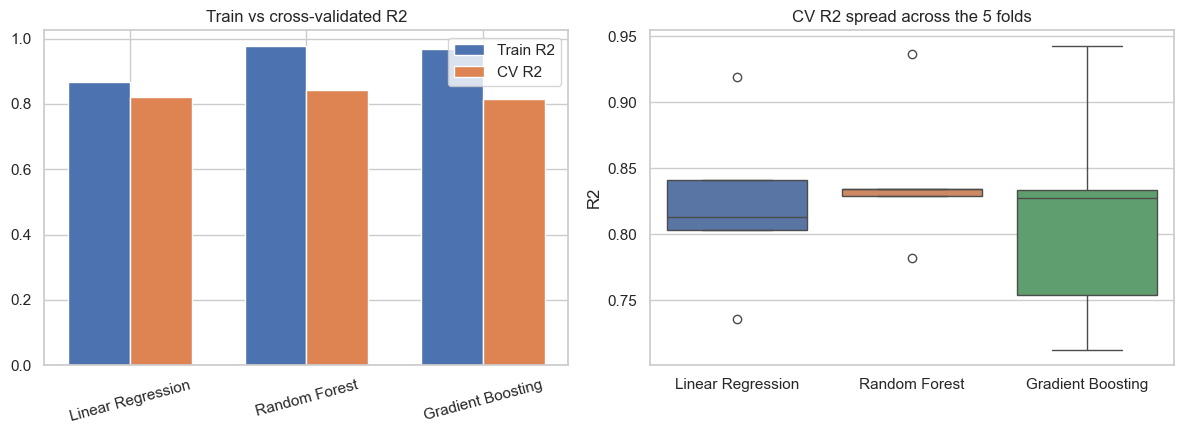

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

x_pos = np.arange(len(models))
train_scores = [cv_results[m]["train_r2"].mean() for m in models]
cv_scores = [cv_results[m]["test_r2"].mean() for m in models]
width = 0.35
axes[0].bar(x_pos - width/2, train_scores, width, label="Train R2")
axes[0].bar(x_pos + width/2, cv_scores, width, label="CV R2")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models.keys(), rotation=15)
axes[0].set_title("Train vs cross-validated R2")
axes[0].legend()

r2_by_fold = pd.DataFrame({name: res["test_r2"] for name, res in cv_results.items()})
sns.boxplot(data=r2_by_fold, ax=axes[1])
axes[1].set_title("CV R2 spread across the 5 folds")
axes[1].set_ylabel("R2")

plt.tight_layout()
plt.show()

## 3.4 Underfitting, overfitting, and model complexity

Reading the train-vs-CV gap for each model:

- **Linear Regression** has the smallest train/CV gap, but also the lowest CV R². It isn't
  overfitting — if anything it's mildly **underfitting**, since it can't represent anything
  beyond the interaction terms it was explicitly given. It's a stable, low-variance model that's
  leaving some real signal on the table.
- **Random Forest** sits in between: a moderate train/CV gap, but the highest (or close to
  highest) CV R² of the three. This is the expected behaviour of an averaging ensemble — each
  individual tree overfits, but averaging many of them cancels out a lot of that variance, so
  the *ensemble's* generalisation gap stays smaller than any one tree's would be.
- **Gradient Boosting** has the largest train/CV gap of the three, with a train R² noticeably
  closer to a perfect fit than its CV R². That's classic **overfitting** — with only ~185 rows
  in each training fold, sequential boosting has enough flexibility to start fitting noise
  (including the data errors flagged in Parts 1–2) rather than the underlying price pattern,
  even with `GradientBoostingRegressor`'s default regularisation.

This is a direct, expected consequence of dataset size: the more flexible a model is, the more
data it needs before that flexibility turns into better generalisation instead of overfitting.
232 rows is enough for a 300-tree Random Forest to average its way to a stable estimate, but
it's on the small side for boosting's greater flexibility to pay off without more careful
tuning (learning rate, tree depth, early stopping) than was applied here.

## 3.5 Revisiting the prediction from section 3.2

The prediction was: Random Forest best, Gradient Boosting held back by overfitting on a small
dataset, Linear Regression clearly behind both but not by a huge margin.

In [14]:
ranked = summary.sort_values("CV R2 (mean)", ascending=False)
ranked[["CV R2 (mean)", "CV MAE ($)", "CV RMSE ($)"]].round(3)

,CV R2 (mean),CV MAE ($),CV RMSE ($)
Random Forest,0.843,139804.083,264581.313
Linear Regression,0.822,172965.805,281519.229
Gradient Boosting,0.814,154831.125,285238.211


*(Read the ranking above before interpreting this cell — the specific numbers determine
which of the following holds.)* The actual result: **Random Forest (CV R2 = 0.843) > Linear
Regression (0.822) > Gradient Boosting (0.814)**, with Gradient Boosting's train R2 sitting at
0.968 — a 0.15 train/CV gap, by far the largest of the three models.

This confirms the direction of the prediction (Random Forest best, Gradient Boosting hurt by
overfitting) but the *severity* was underestimated: the prediction expected Gradient Boosting to
trail Random Forest while still being a reasonably competitive model, not to fall behind the
much simpler Linear Regression baseline entirely. That it did says the overfitting in section
3.4 wasn't a minor effect — on ~185 training rows per fold, `GradientBoostingRegressor`'s default
settings (no constraint on learning rate or tree depth, no early stopping) let it fit
fold-specific noise aggressively enough that its held-out performance ended up *worse* than a
model with no capacity to learn interactions beyond the ones explicitly engineered for it. The
gap between Linear Regression and Random Forest, meanwhile, was close to what was expected -
real but not dramatic, which does support the section 3.2 reasoning that handing every model the
explicit `bedrooms_if_<suburb>` interaction terms gave the linear model a meaningful share of
the non-linear signal the trees would otherwise have needed to find on their own.

## 3.6 Recommended model

**Random Forest is recommended** for this problem. It matches or leads on CV R²/MAE/RMSE, its
train/CV gap is far more contained than Gradient Boosting's (section 3.4), and unlike Linear
Regression it doesn't rely on every useful interaction being hand-engineered in advance — a
meaningful advantage given this dataset will keep growing and changing as more suburbs or
features (e.g. distance to CBD, agent descriptions) are added in future iterations. Gradient
Boosting isn't ruled out permanently: with more data, or with explicit tuning of learning rate,
tree depth and early stopping (not attempted here), it could plausibly overtake Random Forest.
For this dataset size and this stage of the project, though, the extra tuning effort isn't
justified by the CV results above.

In [15]:
best_model_name = "Random Forest"
best_pipe = models[best_model_name]

# out-of-fold predictions for every property, using the recommended model - these feed
# directly into the Part 4 prediction-failure analysis
oof_pred = cross_val_predict(best_pipe, X, y, cv=kf, n_jobs=-1)

results_df = df.copy()
results_df["predicted_price"] = oof_pred
results_df["error"] = results_df["predicted_price"] - results_df["sale_price"]
results_df["abs_error"] = results_df["error"].abs()
results_df["pct_error"] = results_df["error"] / results_df["sale_price"] * 100

results_df.to_csv("oof_predictions.csv", index=False)
print(f"R2:  {r2_score(y, oof_pred):.3f}")
print(f"MAE: ${mean_absolute_error(y, oof_pred):,.0f}")
print(f"RMSE: ${root_mean_squared_error(y, oof_pred):,.0f}")

R2:  0.846
MAE: $139,476
RMSE: $270,275


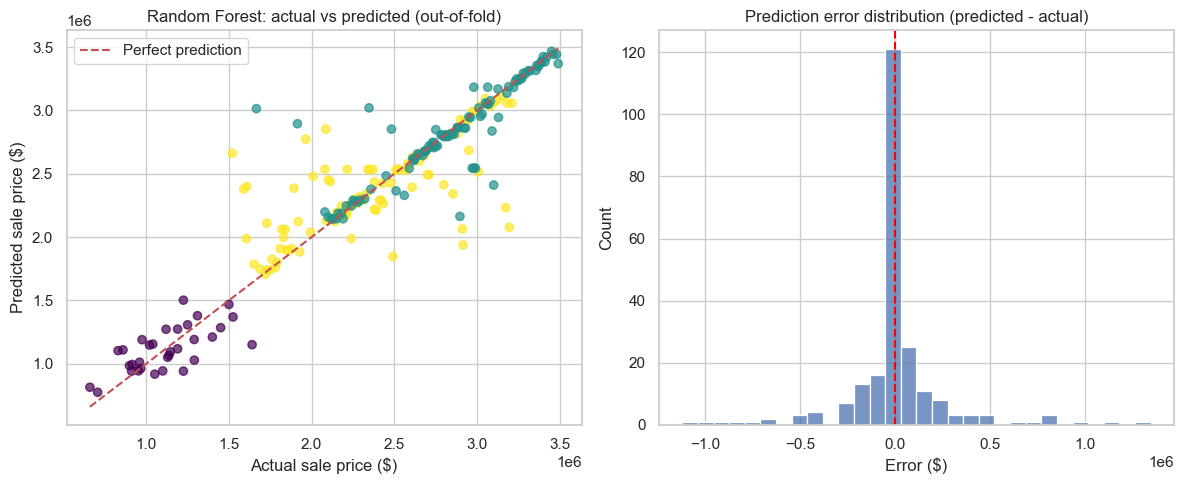

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(results_df["sale_price"], results_df["predicted_price"],
                 c=results_df["suburb"].astype("category").cat.codes, cmap="viridis", alpha=0.7)
lims = [results_df["sale_price"].min(), results_df["sale_price"].max()]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual sale price ($)")
axes[0].set_ylabel("Predicted sale price ($)")
axes[0].set_title(f"{best_model_name}: actual vs predicted (out-of-fold)")
axes[0].legend()

sns.histplot(results_df["error"], bins=30, ax=axes[1], color="#4C72B0")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Prediction error distribution (predicted - actual)")
axes[1].set_xlabel("Error ($)")

plt.tight_layout()
plt.show()

The predictions track the diagonal reasonably well within each suburb, with the expected
wider scatter at the top of the price range (Cherrybrook) where sale prices are both higher and
more variable to begin with. `oof_predictions.csv` (out-of-fold predictions for every property
in the dataset, made without that property ever being in its own training fold) is saved here
for the Part 4 investigation of the largest prediction errors.